In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

In [2]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 483.2 kB/s eta 0:00:0000:0100:02


# Data Exploration

In [5]:
airports = pd.read_csv("data/airports.dat", delimiter=',', 
                       names=['id', 'name', 'city', 'country', 'iata',
                              'icao', 'lat', 'long', 'altitude', 'timezone',
                              'dst', 'tz', 'type', 'source'])
airports.head()

,id,name,city,country,iata,icao,lat,long,altitude,timezone,dst,tz,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


In [6]:
airports.describe()

,id,lat,long,altitude
count,7698.000000,7698.000000,7698.000000,7698.000000
mean,5170.950117,25.808442,-1.390546,1015.873344
std,3777.259930,28.404946,86.519162,1628.775132
min,1.000000,-90.000000,-179.876999,-1266.000000
25%,1993.250000,6.907983,-78.974699,63.000000
50%,4068.000000,34.085701,6.375653,352.000000
75%,7728.750000,47.239551,56.000599,1203.000000
max,14110.000000,89.500000,179.951004,14472.000000


In [7]:
# Assign continent (region group) to airports
# --------------------------
# Rough manual mapping by country region
region_map = {
    'North America': ['United States','Canada','Mexico'],
    'South America': ['Brazil','Argentina','Chile','Colombia','Peru'],
    'Europe': ['United Kingdom','France','Germany','Italy','Spain','Netherlands'],
    'Africa': ['South Africa','Nigeria','Egypt','Kenya','Ethiopia'],
    'Asia': ['China','Japan','India','Thailand','Singapore','United Arab Emirates'],
    'Oceania': ['Australia','New Zealand']
}

def get_region(country):
    for r, c_list in region_map.items():
        if country in c_list:
            return r
    return 'Other'

airports['region'] = airports['country'].apply(get_region)


<function matplotlib.pyplot.show(close=None, block=None)>

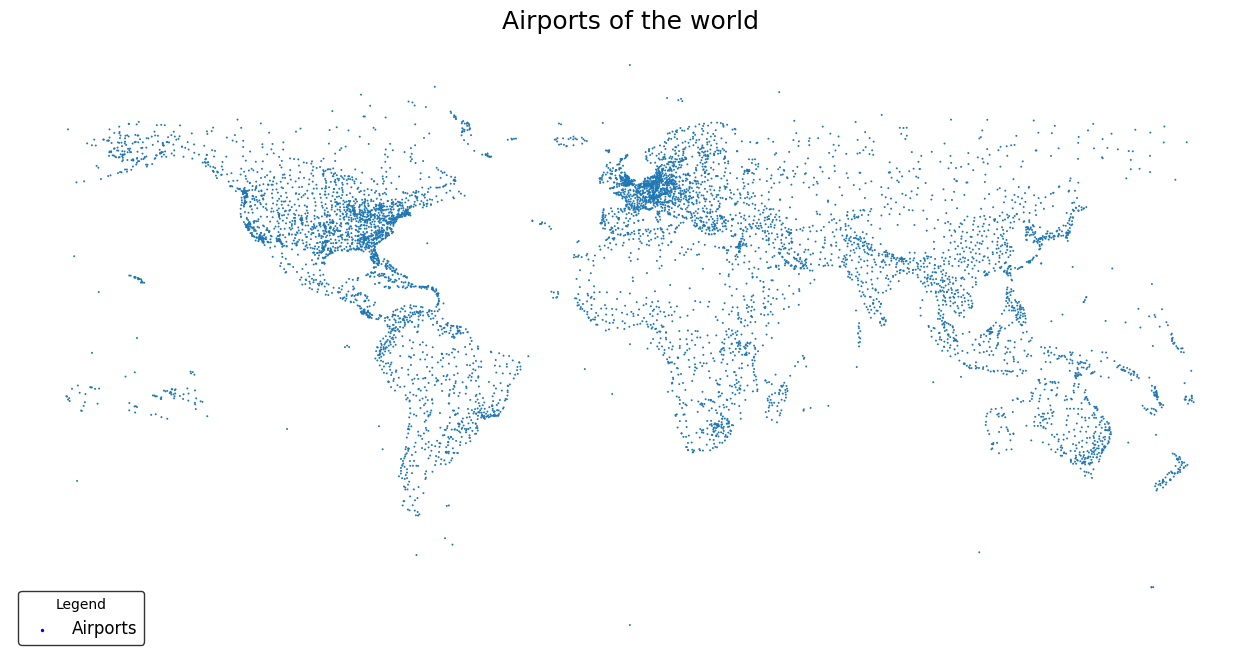

In [8]:
fig, ax = plt.subplots(figsize = (16,8))

ax.scatter(airports['long'], airports['lat'], s=2, alpha=1, edgecolors='none')

# Add legend: create a dummy point
ax.scatter([], [], s=2, color='blue', label='Airports')  # invisible point for legend
ax.legend(loc='lower left', fontsize=12, facecolor='white', edgecolor='black', title='Legend')

ax.axis('off')
ax.set_title("Airports of the world", fontsize = 18)

plt.savefig("Airports of the world.png", dpi=300, bbox_inches='tight')
plt.show

In [9]:
routes = pd.read_csv("data/routes.dat", delimiter=',', names=['airline', 'id', 'source_airport', 'source_airport_id',
                                                               'destination_airport', 'destination_airport_id', 'codeshare',
                                                               'stops', 'equitment'])
routes.head()

,airline,id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equitment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2


# Data Manipulation

In [10]:
# Count routes per airport
src_counts = routes['source_airport'].value_counts()
dst_counts = routes['destination_airport'].value_counts()
total_counts = src_counts.add(dst_counts, fill_value=0)

airports['route_count'] = airports['iata'].map(total_counts).fillna(0)

# Build GeoDataFrame for airports
airports_gdf = gpd.GeoDataFrame(
    airports, geometry=gpd.points_from_xy(airports['long'], airports['lat']),
    crs='EPSG:4326'
)
airports_gdf.head()

,id,name,city,country,iata,icao,lat,long,altitude,timezone,dst,tz,type,source,region,route_count,geometry
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports,Other,10.0,POINT (145.392 -6.08169)
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports,Other,16.0,POINT (145.789 -5.20708)
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports,Other,22.0,POINT (144.29601 -5.82679)
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports,Other,22.0,POINT (146.72598 -6.5698)
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports,Other,102.0,POINT (147.22 -9.44338)


In [11]:
source_airports = airports[['name', 'iata', 'icao', 'lat', 'long', 'region']]
destination_airports = source_airports.copy()
source_airports.columns = [str(col) + '_source' for col in source_airports.columns]
destination_airports.columns = [str(col) + '_destination' for col in destination_airports.columns]

In [12]:
routes = routes[['source_airport', 'destination_airport']]
routes = pd.merge(routes, source_airports, left_on='source_airport', right_on='iata_source')
routes = pd.merge(routes, destination_airports, left_on='destination_airport', 
                  right_on='iata_destination')

#print(routes.columns)
routes.head()

,source_airport,destination_airport,name_source,iata_source,icao_source,lat_source,long_source,region_source,name_destination,iata_destination,icao_destination,lat_destination,long_destination,region_destination
0,AER,KZN,Sochi International Airport,AER,URSS,43.449902,39.956600,Other,Kazan International Airport,KZN,UWKD,55.606201,49.278702,Other
1,ASF,KZN,Astrakhan Airport,ASF,URWA,46.283298,48.006302,Other,Kazan International Airport,KZN,UWKD,55.606201,49.278702,Other
2,ASF,MRV,Astrakhan Airport,ASF,URWA,46.283298,48.006302,Other,Mineralnyye Vody Airport,MRV,URMM,44.225101,43.081902,Other
3,CEK,KZN,Chelyabinsk Balandino Airport,CEK,USCC,55.305801,61.503300,Other,Kazan International Airport,KZN,UWKD,55.606201,49.278702,Other
4,CEK,OVB,Chelyabinsk Balandino Airport,CEK,USCC,55.305801,61.503300,Other,Tolmachevo Airport,OVB,UNNT,55.012600,82.650703,Other


In [13]:
# Create route geometries
geometry = [LineString([[routes.iloc[i]['long_source'], routes.iloc[i]['lat_source']], 
                        [routes.iloc[i]['long_destination'], 
                         routes.iloc[i]['lat_destination']]]) for i in range(routes.shape[0])]
routes = gpd.GeoDataFrame(routes, geometry=geometry, crs='EPSG:4326')
print(routes)

      source_airport destination_airport                       name_source  \
0                AER                 KZN       Sochi International Airport   
1                ASF                 KZN                 Astrakhan Airport   
2                ASF                 MRV                 Astrakhan Airport   
3                CEK                 KZN     Chelyabinsk Balandino Airport   
4                CEK                 OVB     Chelyabinsk Balandino Airport   
...              ...                 ...                               ...   
66929            WYA                 ADL                   Whyalla Airport   
66930            DME                 FRU  Domodedovo International Airport   
66931            FRU                 DME       Manas International Airport   
66932            FRU                 OSS       Manas International Airport   
66933            OSS                 FRU                       Osh Airport   

      iata_source icao_source  lat_source  long_source region_s

In [14]:
routes.head()

,source_airport,destination_airport,name_source,iata_source,icao_source,lat_source,long_source,region_source,name_destination,iata_destination,icao_destination,lat_destination,long_destination,region_destination,geometry
0,AER,KZN,Sochi International Airport,AER,URSS,43.449902,39.956600,Other,Kazan International Airport,KZN,UWKD,55.606201,49.278702,Other,"LINESTRING (39.9566 43.4499, 49.2787 55.6062)"
1,ASF,KZN,Astrakhan Airport,ASF,URWA,46.283298,48.006302,Other,Kazan International Airport,KZN,UWKD,55.606201,49.278702,Other,"LINESTRING (48.0063 46.2833, 49.2787 55.6062)"
2,ASF,MRV,Astrakhan Airport,ASF,URWA,46.283298,48.006302,Other,Mineralnyye Vody Airport,MRV,URMM,44.225101,43.081902,Other,"LINESTRING (48.0063 46.2833, 43.0819 44.2251)"
3,CEK,KZN,Chelyabinsk Balandino Airport,CEK,USCC,55.305801,61.503300,Other,Kazan International Airport,KZN,UWKD,55.606201,49.278702,Other,"LINESTRING (61.5033 55.3058, 49.2787 55.6062)"
4,CEK,OVB,Chelyabinsk Balandino Airport,CEK,USCC,55.305801,61.503300,Other,Tolmachevo Airport,OVB,UNNT,55.012600,82.650703,Other,"LINESTRING (61.5033 55.3058, 82.6507 55.0126)"


In [15]:
region_colors = {
    'North America': '#00e5ff',  # cyan
    'South America': '#00bfff',  # deep sky blue
    'Europe': '#ff66cc',         # pink
    'Africa': '#ffff33',         # bright yellow
    'Asia': '#ff6600',            # orange
    'Oceania': '#ff0033',         # bright red
    'Other': '#bbbbbb'            # light ash
}

# Data Visualisation

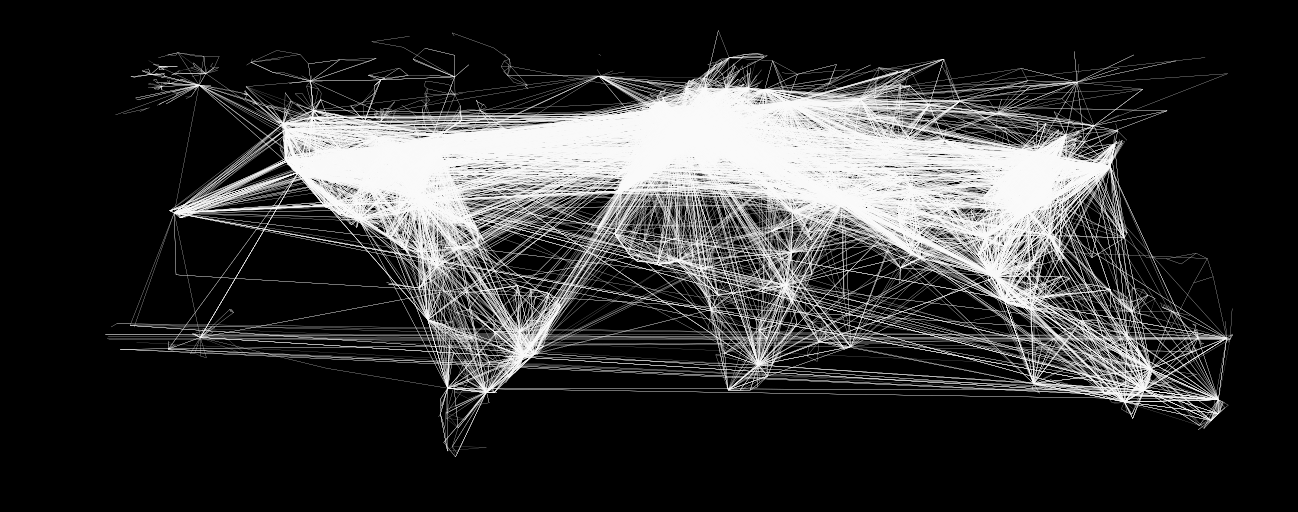

In [16]:
fig, ax = plt.subplots ( figsize = (16, 8), facecolor = "black")
ax.patch.set_facecolor('black')
routes.plot(ax=ax, color='white', linewidth=0.1)

plt.setp(ax.spines.values(), color='black')
plt.setp([ax.get_xticklines(), ax.get_yticklines()], color='black')

# Save figure
plt.savefig("Global_Airport_Routes_flat.png", dpi=300, bbox_inches='tight', facecolor='black')

plt.show()

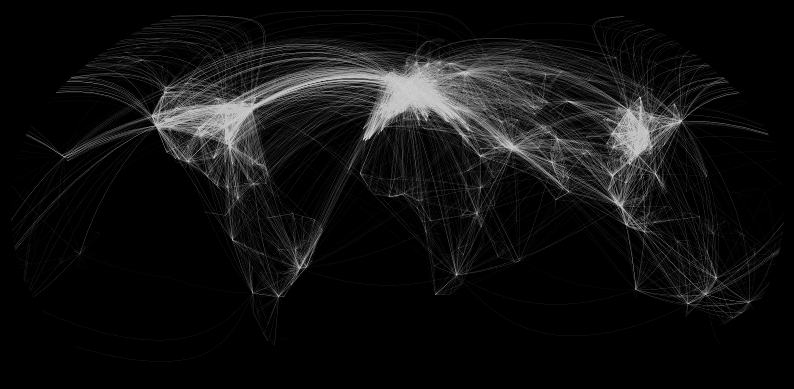

In [17]:
# Map and figure setup
fig, ax = plt.subplots(figsize=(10, 5), facecolor='black', 
                       subplot_kw={'projection': ccrs.Robinson()})

# Set black background
ax.set_facecolor('black')

# Plot routes
routes.plot(
    ax=ax,
    transform=ccrs.Geodetic(),
    color='white',
    linewidth=0.1,
    alpha=0.1
)

plt.setp(ax.spines.values(), color='black')
plt.setp([ax.get_xticklines(), ax.get_yticklines()], color='black')

# Save figure
plt.savefig("Global_Airport_Routes_nocolor.png", dpi=300, bbox_inches='tight', facecolor='black')

plt.show()

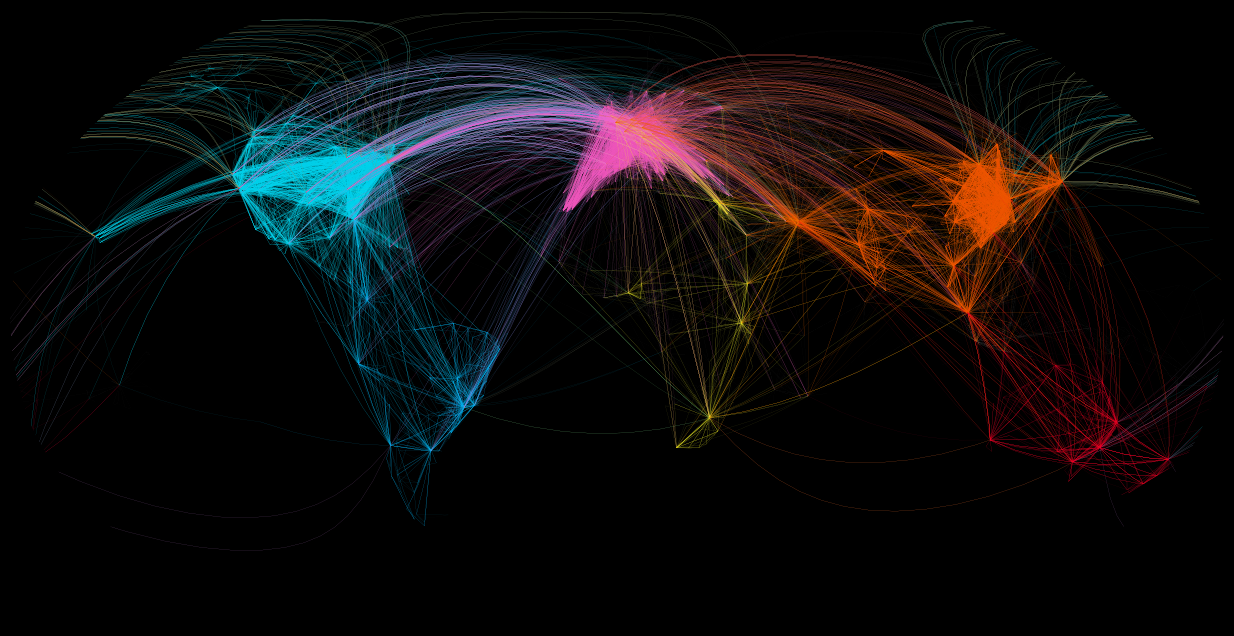

In [18]:
fig, ax = plt.subplots(figsize=(16, 8),
                       subplot_kw={'projection': ccrs.Robinson()},
                       facecolor='black')
ax.set_facecolor('black')

# Plot 'Other' first (ash + low alpha)
subset = routes[routes['region_source'] == 'Other']
subset.plot(ax=ax, transform=ccrs.Geodetic(),
            color=region_colors['Other'], linewidth=0.1, alpha=0.05)

# Plot routes colored by source region
for region, color in region_colors.items():
    if region == 'Other':
        continue
    subset = routes[routes['region_source'] == region]
    subset.plot(ax=ax, transform=ccrs.Geodetic(),
                color=color, linewidth=0.1, alpha=0.3)

ax.set_global()
ax.axis('off')

# Save figure
plt.savefig("Global_Airport_Routes.png", dpi=300, bbox_inches='tight', facecolor='black')

plt.show()

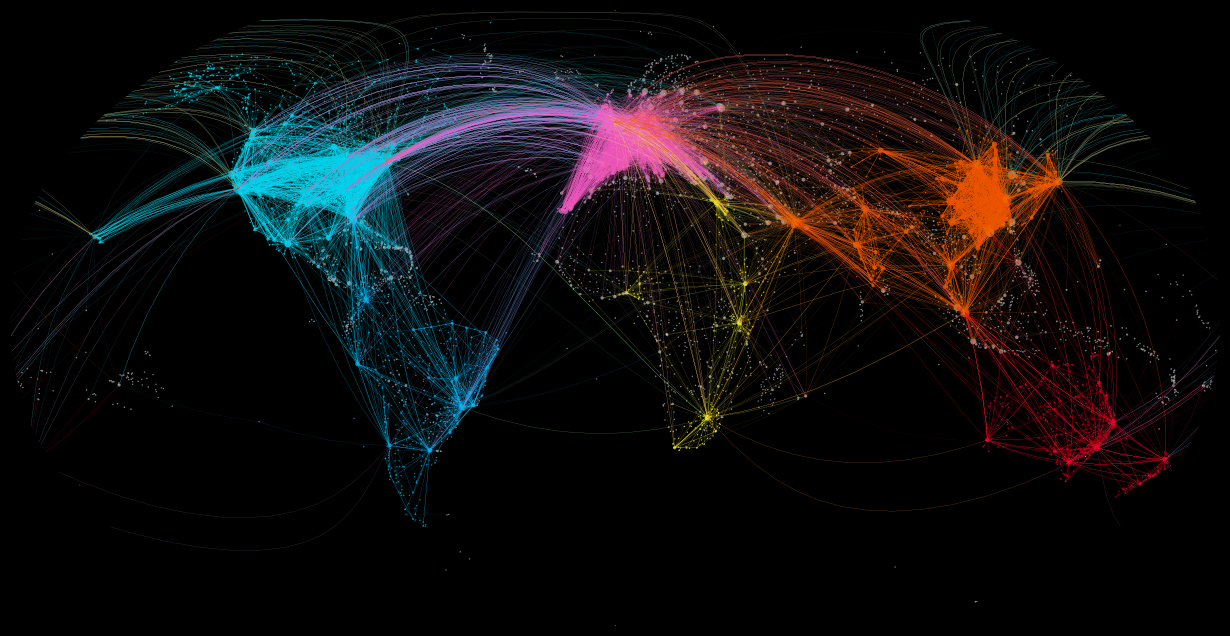

In [19]:
fig, ax = plt.subplots(figsize=(16, 8),
                       subplot_kw={'projection': ccrs.Robinson()},
                       facecolor='black')
ax.set_facecolor('black')

# Plot 'Other' routes first (ash faint)
other = routes[routes['region_source'] == 'Other']
other.plot(ax=ax, transform=ccrs.Geodetic(),
           color=region_colors['Other'], linewidth=0.1, alpha=0.05)

# Plot colored routes on top
for region, color in region_colors.items():
    if region == 'Other':
        continue
    subset = routes[routes['region_source'] == region]
    subset.plot(ax=ax, transform=ccrs.Geodetic(),
                color=color, linewidth=0.1, alpha=0.3)

# Plot airports as dots (size by route_count, color by region)
for region, color in region_colors.items():
    a = airports_gdf[airports_gdf['region'] == region]
    a.plot(ax=ax, transform=ccrs.PlateCarree(),
           markersize=a['route_count']*0.05 + 1,  # scaling factor
           color=color, alpha=0.7, edgecolor='none')

ax.set_global()
ax.axis('off')

# Save figure
plt.savefig("Global_Airport_Routes_dots.png", dpi=300, bbox_inches='tight', facecolor='black')

plt.show()

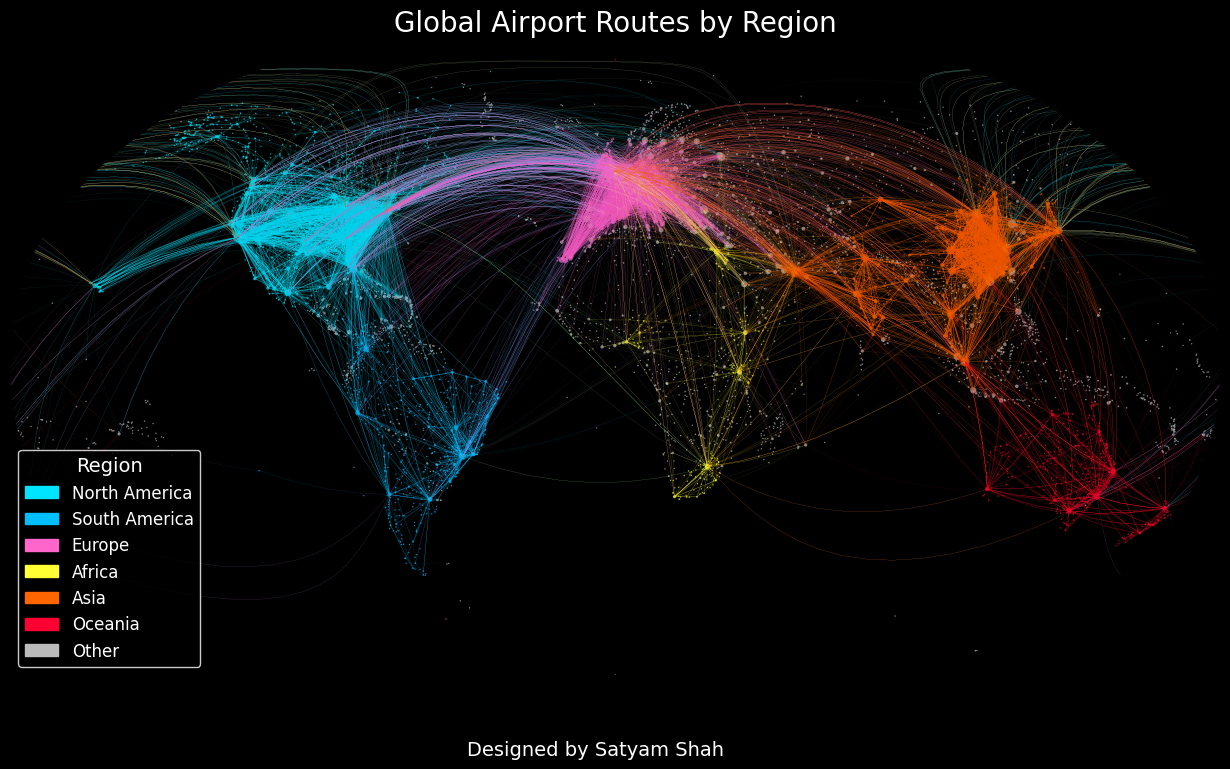

In [20]:
fig, ax = plt.subplots(figsize=(16, 8),
                       subplot_kw={'projection': ccrs.Robinson()},
                       facecolor='black')
ax.set_facecolor('black')

# Plot 'Other' routes first (ash faint)
other = routes[routes['region_source'] == 'Other']
other.plot(ax=ax, transform=ccrs.Geodetic(),
           color=region_colors['Other'], linewidth=0.1, alpha=0.05)

# Plot colored routes on top
for region, color in region_colors.items():
    if region == 'Other':
        continue
    subset = routes[routes['region_source'] == region]
    subset.plot(ax=ax, transform=ccrs.Geodetic(),
                color=color, linewidth=0.1, alpha=0.3)

# Plot airports as dots (size by route_count, color by region)
for region, color in region_colors.items():
    a = airports_gdf[airports_gdf['region'] == region]
    a.plot(ax=ax, transform=ccrs.PlateCarree(),
           markersize=a['route_count']*0.05 + 1,  # scaling factor
           color=color, alpha=0.7, edgecolor='none')

# Create legend handles
handles = []
for region, color in region_colors.items():
    handles.append(mpatches.Patch(color=color, label=region))

ax.set_global()
ax.axis('off')

# ----- Add legend for regions -----
handles = [mpatches.Patch(color=color, label=region) 
           for region, color in region_colors.items()]

# Create legend
legend = ax.legend(handles=handles, loc='lower left', 
                   fontsize=12, facecolor='black', framealpha=0.8, edgecolor='white',
                   title='Region', title_fontsize=14)

# Set colors directly after creation
plt.setp(legend.get_title(), color='white')  # legend title color
for text in legend.get_texts():
    text.set_color('white')  # legend labels
    
# Add title at top
ax.set_title("Global Airport Routes by Region", fontsize=20, color='white', pad=20)

# Add name at bottom
fig.text(0.5, 0.01, "Designed by Satyam Shah", fontsize=14, color='white', ha='center')

# Save figure
plt.savefig("Global_Airport_Routes_Final.png", dpi=300, bbox_inches='tight', facecolor='black')

plt.show()